# Introdução

O Exame Nacional do Ensino Médio (ENEM) é uma das principais ferramentas de acesso ao ensino superior no Brasil. Realizado anualmente por milhões de estudantes egressos do ensino médio, o exame funciona como um processo seletivo nacional, no qual as maiores pontuações possibilitam o ingresso em instituições mais concorridas e prestigiadas.

Entretanto, o desempenho no ENEM vai muito além da preparação individual: ele reflete as desigualdades sociais, econômicas e educacionais presentes no país. Fatores como renda familiar, tipo de escola frequentada, acesso à internet, raça, localização geográfica e ocupação dos responsáveis estão fortemente relacionados às oportunidades de aprendizado e, consequentemente, às notas obtidas. Em resposta a esse cenário, políticas públicas como o sistema de cotas buscam promover maior equidade no acesso ao ensino superior.

# Objetivo

Este projeto dá continuidade ao Projeto 2, ampliando a análise exploratória anteriormente desenvolvida. Agora, o foco será a construção de um modelo preditivo capaz de estimar a Média Ponderada via ENEM (MPE) com base em variáveis socioeconômicas, demográficas e educacionais previamente selecionadas. Assim, pretende-se investigar quais fatores mais influenciam o desempenho dos participantes e em que medida é possível prever a MPE de um candidato com base em seu perfil.

Esse perfil e seus fatores estão relacionados há (como previamente falado): 

- **Aspectos socioeconômicos**: Fala-se sobre as condições financeiras e contexto familiar e eduacação, como por exemplo: Renda Familiar, Escolaridade dos Pais, Quantidade de bens na casa e etc.
- **Aspectos educacionais**: Histórico escolar principalmente
- **Aspectos demográficos**: Perfil pessoal do candidato, como idade, raça, sexo.

# Pergunta norteadora

É possível prever a Média Ponderada via ENEM (MPE) de um participante com base em seu perfil socioeconômico, demográfico e educacional? Quais dessas características têm maior impacto no resultado final?

# Análise do Projeto 2

# **Projeto 2 – Análise do Perfil dos Candidatos do ENEM (2019 e 2023)**

## **Objetivo do Projeto**
Analisar o perfil dos candidatos do ENEM 2019 e 2023 para prever, por meio de análise exploratória, a **Média Ponderada via ENEM** dos candidatos ingressando em **Administração e Economia**.

---

## **Features Selecionadas**

Foram escolhidas as seguintes variáveis para a análise:

- **`TP_SEXO`**: Analisar possíveis diferenças de desempenho entre gêneros.  
- **`TP_COR_RACA`**: Considerar o impacto das desigualdades raciais no desempenho.  
- **`TP_DEPENDENCIA_ADM_ESC`** e **`TP_ESCOLA`**: Relevantes em um país desigual, pois refletem diferenças estruturais na educação.  
- **`TP_LOCALIZACAO_ESC`**: Indica o contexto urbano ou rural, importante devido às diferenças de acesso à educação.  
- **`Q001`, `Q002`, `Q003`, `Q004`, `Q022`, `Q025`**: Representam a escolaridade dos pais e o histórico familiar, fatores que influenciam as condições de estudo.  
- **Demais variáveis necessárias para cálculo da nota**:  
  `TP_ST_CONCLUSAO`, `TP_STATUS_REDACAO`, `TP_PRESENCA_CN`, `TP_PRESENCA_CH`, `TP_PRESENCA_MT`, `TP_PRESENCA_LC`, `IN_TREINEIRO`.

---

## **Resultados Obtidos**

A análise e os gráficos revelaram padrões relevantes nos seguintes aspectos:

---

### **Escolaridade do Pai**

<p align="center">
  <img src="Screenshot_1.png" alt="Escolaridade do Pai" width="500">
</p>

As notas aumentam conforme cresce o nível de escolaridade do pai, sugerindo que pais mais instruídos tendem a oferecer melhores condições de estudo e incentivo ao aprendizado, possivelmente ligados a fatores socioeconômicos.

---

### **Sexo**

#### 2019
<p align="center">
  <img src="Screenshot_4.png" alt="Sexo 2019" width="450">
</p>

#### 2023
<p align="center">
  <img src="Screenshot_2.png" alt="Sexo 2023" width="450">
</p>

A tabela mostra que os homens tiveram, em média, **12,63 pontos** a mais que as mulheres. Apesar de as mulheres serem maioria, os homens apresentaram notas superiores em todos os percentis (mínimo, mediana, 75% e máximo).  
O desvio padrão masculino foi maior, possivelmente devido à amostra menor.

---

### **Cor e Raça**

#### 2019
<p align="center">
  <img src="Screenshot_5.png" alt="Raça 2019" width="450">
</p>

#### 2023
<p align="center">
  <img src="Screenshot_3.png" alt="Raça 2023" width="450">
</p>

Candidatos **brancos** tiveram a maior média, superando o segundo grupo por **27,82 pontos**.  
Os **pardos** foram o grupo mais numeroso, enquanto os **indígenas** apresentaram a menor média, mesmo com o menor desvio padrão e maior nota máxima.

---

### **Localização da Escola (Urbano x Rural)**

<p align="center">
  <img src="Screenshot_6.png" alt="Localização" width="500">
</p>

A maioria dos candidatos estudou em áreas **urbanas**, com desempenho médio superior aos de áreas rurais.  
O desvio padrão urbano foi maior, enquanto os candidatos do meio rural tiveram média **27,67 pontos menor**, mas **nota mínima mais alta** que a dos urbanos.

---

### **Tipo de Escola e Renda Familiar**

<p align="center">
  <img src="Screenshot_7.png" alt="Tipo de Escola" width="500">
</p>

Candidatos de **escolas privadas** apresentaram o melhor desempenho, com média **19,22 pontos** acima do segundo grupo.  
Além disso, o desempenho cresce conforme aumenta a **renda familiar**, embora o candidato com a **maior nota** pertença à faixa de renda de até **R$ 15.840,00**.

---


In [1]:
# PARA DEIXAR EM GRAFICO NAO EDITAVEL
%matplotlib inline
import os
import pandas as pd
import numpy as np
from scipy.stats import norm, probplot
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from mpl_toolkits.mplot3d import Axes3D

# Para ter melhor print
from IPython.display import display

from math import sqrt
df23 = pd.read_csv('enem_23.csv')
df23.dtypes

Unnamed: 0                  int64
MPE                       float64
TP_SEXO                    object
TP_COR_RACA                 int64
TP_ST_CONCLUSAO             int64
TP_DEPENDENCIA_ADM_ESC    float64
TP_ESCOLA                   int64
TP_LOCALIZACAO_ESC        float64
Q001                       object
Q002                       object
Q003                       object
Q004                       object
Q006                       object
Q022                       object
Q025                       object
dtype: object

Filtro

In [2]:
X = df23.drop('MPE', axis = 1)
Y = df23['MPE']
Xf = pd.get_dummies(X, drop_first=True, dtype=float)

x_train , x_test , y_train , y_test = train_test_split(Xf, Y, test_size=0.2, random_state=42)

# print("Any NaN in x_train?", x_train.isna().any().any())
# print("Any NaN in y_train?", y_train.isna().any())
# print("Any inf in x_train?", np.isinf(x_train.to_numpy()).any())
# print("Any inf in y_train?", np.isinf(y_train.to_numpy()).any())
# print(x_train.dtypes.value_counts())
# print("Colunas constantes:", const_cols)

const_cols = [c for c in x_train.columns if x_train[c].nunique() <= 1]
mask = x_train.isna().any(axis=1) | y_train.isna()
x_train = x_train[~mask].reset_index(drop=True)
y_train = y_train[~mask].reset_index(drop=True)

# print("Any NaN in x_train?", x_train.isna().any().any())

x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)
modelo = sm.OLS(y_train, x_train)
result = modelo.fit()
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:                    MPE   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     5560.
Date:                Thu, 13 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:51:35   Log-Likelihood:            -3.2230e+06
No. Observations:              554331   AIC:                         6.446e+06
Df Residuals:                  554279   BIC:                         6.447e+06
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Unnamed: 0             -1.28

*Analise do sumario*
percebemos que os valores de p estão todos menores que 10%, portanto, não é necessário fazer a remoção ed variaveis. Conclusão: todas as variaveis escolhidas são relevantes para a discussão.

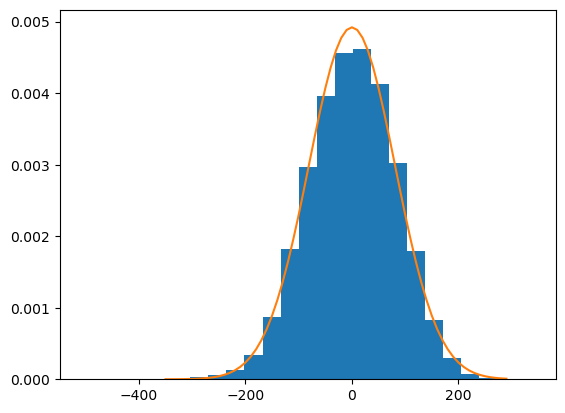

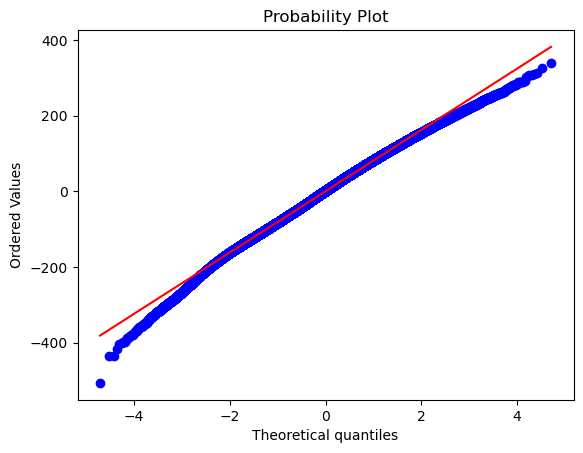

In [3]:
residuos = result.resid

mu = residuos.mean()
sigma = residuos.std()

plt.hist(residuos, bins = 25, density = True)
faixa = np.arange(-350,300, 10)
plt.plot(faixa, stats.norm.pdf(faixa, loc = mu, scale = sigma))

plt.show()

stats.probplot(residuos, dist = 'norm', plot = plt)

plt.show()